# Chapter 1.8: Datasets & Benchmarking

## Learning Objectives

By the end of this notebook, you will be able to:

1. Describe major public RecSys datasets: MovieLens, Amazon Reviews, Criteo, Taobao
2. Compare dataset characteristics: sparsity, feature types, and scale
3. Generate synthetic industrial-scale datasets with realistic distributions
4. Apply proper benchmarking methodology for fair model comparison
5. Understand the importance of reproducibility in RecSys research
6. Use RecBole and LensKit frameworks for standardized evaluation
7. Design evaluation protocols that match production requirements

## Prerequisites

- Chapters 1.1-1.7 (all previous chapters)
- Understanding of evaluation metrics (Chapter 1.1)
- Understanding of data splitting (Chapter 1.2)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/hideak1/rec_system/blob/main/notebooks/part1/chapter_1.8_datasets.ipynb)
[![Download](https://img.shields.io/badge/Download-Notebook-blue)](https://github.com/hideak1/rec_system/raw/main/notebooks/part1/chapter_1.8_datasets.ipynb)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter, defaultdict
from scipy import sparse

np.random.seed(42)

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.grid'] = True

print("All imports successful!")

All imports successful!


## 1. Major Public Datasets

### MovieLens (GroupLens)
The most widely used RecSys benchmark.

| Version | Users | Items | Ratings | Density | Features |
|---|---|---|---|---|---|
| ML-100K | 943 | 1,682 | 100K | 6.3% | Demographics, genres |
| ML-1M | 6,040 | 3,706 | 1M | 4.5% | Demographics, genres |
| ML-25M | 162,541 | 62,423 | 25M | 0.25% | Tags, timestamps |

### Amazon Reviews
Product reviews from Amazon.com across multiple categories.

| Stat | Value |
|---|---|
| Users | ~21M |
| Items | ~10M |
| Reviews | ~83M |
| Categories | 29 |
| Features | Review text, ratings, timestamps, product metadata |

### Criteo
Click-through rate prediction dataset from display advertising.

| Stat | Value |
|---|---|
| Samples | ~45M (1 day) |
| Features | 13 numerical + 26 categorical |
| Label | Click/No-click |
| Density | N/A (tabular) |

### Taobao (Alibaba)
User behavior data from Alibaba's e-commerce platform.

| Stat | Value |
|---|---|
| Users | ~1M |
| Items | ~4M |
| Behaviors | ~100M (click, purchase, add-to-cart, favorite) |
| Features | Item categories, behavior types, timestamps |

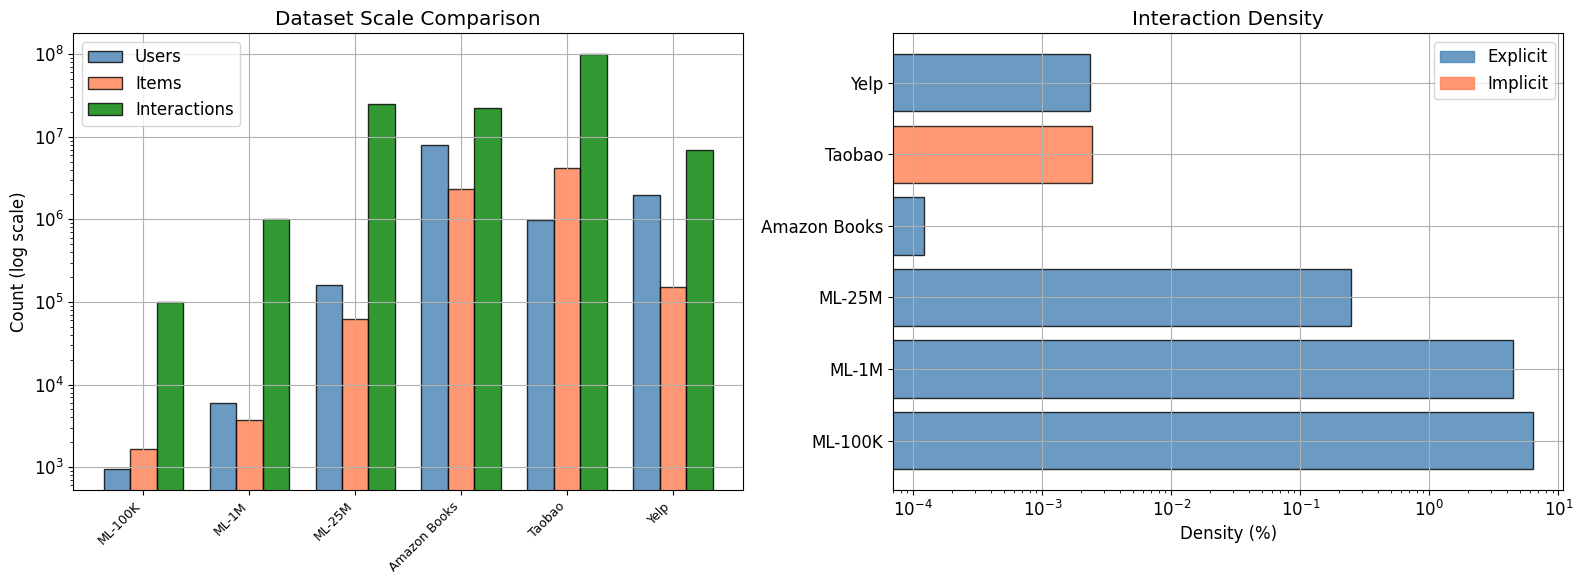


Density values:
  ML-100K: 6.304669%
  ML-1M: 4.467429%
  ML-25M: 0.246395%
  Amazon Books: 0.000120%
  Taobao: 0.002436%
  Yelp: 0.002339%


In [2]:
# Compare dataset characteristics
datasets = {
    'ML-100K': {'users': 943, 'items': 1682, 'interactions': 100000, 
                'type': 'Explicit', 'domain': 'Movies'},
    'ML-1M': {'users': 6040, 'items': 3706, 'interactions': 1000000,
              'type': 'Explicit', 'domain': 'Movies'},
    'ML-25M': {'users': 162541, 'items': 62423, 'interactions': 25000000,
               'type': 'Explicit', 'domain': 'Movies'},
    'Amazon Books': {'users': 8026324, 'items': 2330066, 'interactions': 22507155,
                     'type': 'Explicit', 'domain': 'E-commerce'},
    'Criteo': {'users': 45000000, 'items': 0, 'interactions': 45000000,
               'type': 'Implicit', 'domain': 'Ads'},
    'Taobao': {'users': 987994, 'items': 4162024, 'interactions': 100150807,
               'type': 'Implicit', 'domain': 'E-commerce'},
    'Yelp': {'users': 1987897, 'items': 150346, 'interactions': 6990280,
             'type': 'Explicit', 'domain': 'Local Biz'},
}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scale comparison (log)
names = [n for n in datasets if datasets[n]['items'] > 0]
users = [datasets[n]['users'] for n in names]
items = [datasets[n]['items'] for n in names]
interactions = [datasets[n]['interactions'] for n in names]

x = np.arange(len(names))
width = 0.25

axes[0].bar(x - width, users, width, label='Users', color='steelblue', edgecolor='black', alpha=0.8)
axes[0].bar(x, items, width, label='Items', color='coral', edgecolor='black', alpha=0.8)
axes[0].bar(x + width, interactions, width, label='Interactions', color='green', edgecolor='black', alpha=0.8)
axes[0].set_yscale('log')
axes[0].set_xticks(x)
axes[0].set_xticklabels(names, rotation=45, ha='right', fontsize=9)
axes[0].set_ylabel('Count (log scale)')
axes[0].set_title('Dataset Scale Comparison')
axes[0].legend()

# Density comparison
densities = [datasets[n]['interactions'] / (datasets[n]['users'] * datasets[n]['items']) * 100
             for n in names]

colors = ['steelblue' if datasets[n]['type'] == 'Explicit' else 'coral' for n in names]
axes[1].barh(names, densities, color=colors, edgecolor='black', alpha=0.8)
axes[1].set_xlabel('Density (%)')
axes[1].set_title('Interaction Density')
axes[1].set_xscale('log')

# Legend
import matplotlib.patches as mpatches
p1 = mpatches.Patch(color='steelblue', alpha=0.8, label='Explicit')
p2 = mpatches.Patch(color='coral', alpha=0.8, label='Implicit')
axes[1].legend(handles=[p1, p2])

plt.tight_layout()
plt.show()

print("\nDensity values:")
for name, density in zip(names, densities):
    print(f"  {name}: {density:.6f}%")

> **💡 Concept:** Notice the massive difference in density. ML-100K at 6.3% is considered "dense" by RecSys standards. Real industrial datasets like Amazon and Taobao have densities below 0.001%. This extreme sparsity is the fundamental challenge of recommendation.

## 2. Building Synthetic Industrial-Scale Datasets

Real industrial datasets are often proprietary. We can generate realistic synthetic data for research and experimentation.

Key properties to replicate:
- Power-law distributions for user activity and item popularity
- Temporal dynamics (concept drift)
- Multiple feedback types (click, purchase, rating)
- Rich feature spaces (sparse categorical + dense numerical)

In [3]:
class SyntheticDatasetGenerator:
    """Generate realistic synthetic recommendation datasets."""
    
    def __init__(self, n_users=10000, n_items=5000, n_user_features=5,
                 n_item_features=5, n_context_features=3, seed=42):
        np.random.seed(seed)
        self.n_users = n_users
        self.n_items = n_items
        
        # Latent factors (ground truth)
        self.n_factors = 8
        self.user_factors = np.random.randn(n_users, self.n_factors) * 0.5
        self.item_factors = np.random.randn(n_items, self.n_factors) * 0.5
        self.user_bias = np.random.randn(n_users) * 0.3
        self.item_bias = np.random.randn(n_items) * 0.3
        self.global_bias = 0.1  # Base CTR
        
        # Item popularity (power law)
        self.item_popularity = np.random.power(0.3, n_items)
        self.item_popularity /= self.item_popularity.sum()
        
        # User activity (power law)
        self.user_activity = np.random.power(0.5, n_users)
        
        # Generate features
        self._generate_user_features(n_user_features)
        self._generate_item_features(n_item_features)
    
    def _generate_user_features(self, n_features):
        self.user_features = {
            'age_bucket': np.random.randint(0, 6, self.n_users),
            'gender': np.random.randint(0, 3, self.n_users),
            'city_tier': np.random.randint(0, 5, self.n_users),
            'registration_days': np.random.exponential(365, self.n_users).astype(int),
            'avg_session_duration': np.random.lognormal(3, 1, self.n_users),
        }
    
    def _generate_item_features(self, n_features):
        self.item_features = {
            'category': np.random.randint(0, 20, self.n_items),
            'brand': np.random.randint(0, 200, self.n_items),
            'price_bucket': np.random.randint(0, 10, self.n_items),
            'age_days': np.random.exponential(100, self.n_items).astype(int),
            'avg_rating': np.clip(np.random.normal(3.8, 0.5, self.n_items), 1, 5),
        }
    
    def generate_interactions(self, n_interactions=100000):
        """Generate click-through data with realistic patterns."""
        # Sample users proportional to activity
        user_probs = self.user_activity / self.user_activity.sum()
        user_ids = np.random.choice(self.n_users, n_interactions, p=user_probs)
        
        # Sample items proportional to popularity
        item_ids = np.random.choice(self.n_items, n_interactions, p=self.item_popularity)
        
        # Context features
        hour_of_day = np.random.randint(0, 24, n_interactions)
        day_of_week = np.random.randint(0, 7, n_interactions)
        device = np.random.choice(3, n_interactions, p=[0.6, 0.3, 0.1])  # mobile, desktop, tablet
        
        # Generate labels (CTR)
        # True affinity from latent factors
        affinities = np.array([
            self.user_factors[u] @ self.item_factors[i] + self.user_bias[u] + self.item_bias[i]
            for u, i in zip(user_ids, item_ids)
        ])
        
        # Convert to probability with sigmoid
        click_probs = 1 / (1 + np.exp(-(self.global_bias + affinities * 0.5)))
        # Add noise from context
        hour_effect = 0.02 * np.sin((hour_of_day - 6) * np.pi / 12)
        click_probs = np.clip(click_probs + hour_effect, 0.01, 0.5)
        
        labels = (np.random.random(n_interactions) < click_probs).astype(int)
        
        # Timestamps (spread over 30 days)
        timestamps = np.sort(np.random.randint(0, 30 * 24 * 3600, n_interactions))
        
        return {
            'user_id': user_ids,
            'item_id': item_ids,
            'label': labels,
            'timestamp': timestamps,
            'hour': hour_of_day,
            'day_of_week': day_of_week,
            'device': device,
            # User features (looked up per interaction)
            'user_age_bucket': self.user_features['age_bucket'][user_ids],
            'user_gender': self.user_features['gender'][user_ids],
            'user_city_tier': self.user_features['city_tier'][user_ids],
            # Item features
            'item_category': self.item_features['category'][item_ids],
            'item_brand': self.item_features['brand'][item_ids],
            'item_price_bucket': self.item_features['price_bucket'][item_ids],
        }


# Generate dataset
generator = SyntheticDatasetGenerator(n_users=10000, n_items=5000)
data = generator.generate_interactions(n_interactions=200000)

print(f"Generated synthetic CTR dataset:")
print(f"  Interactions: {len(data['label']):,}")
print(f"  Unique users: {len(np.unique(data['user_id'])):,}")
print(f"  Unique items: {len(np.unique(data['item_id'])):,}")
print(f"  Click rate: {data['label'].mean():.4f}")
print(f"  Time span: {(data['timestamp'][-1] - data['timestamp'][0]) / 86400:.1f} days")
print(f"  Features: {[k for k in data.keys() if k not in ['label', 'timestamp']]}")

Generated synthetic CTR dataset:
  Interactions: 200,000
  Unique users: 8,877
  Unique items: 4,036
  Click rate: 0.4726
  Time span: 30.0 days
  Features: ['user_id', 'item_id', 'hour', 'day_of_week', 'device', 'user_age_bucket', 'user_gender', 'user_city_tier', 'item_category', 'item_brand', 'item_price_bucket']


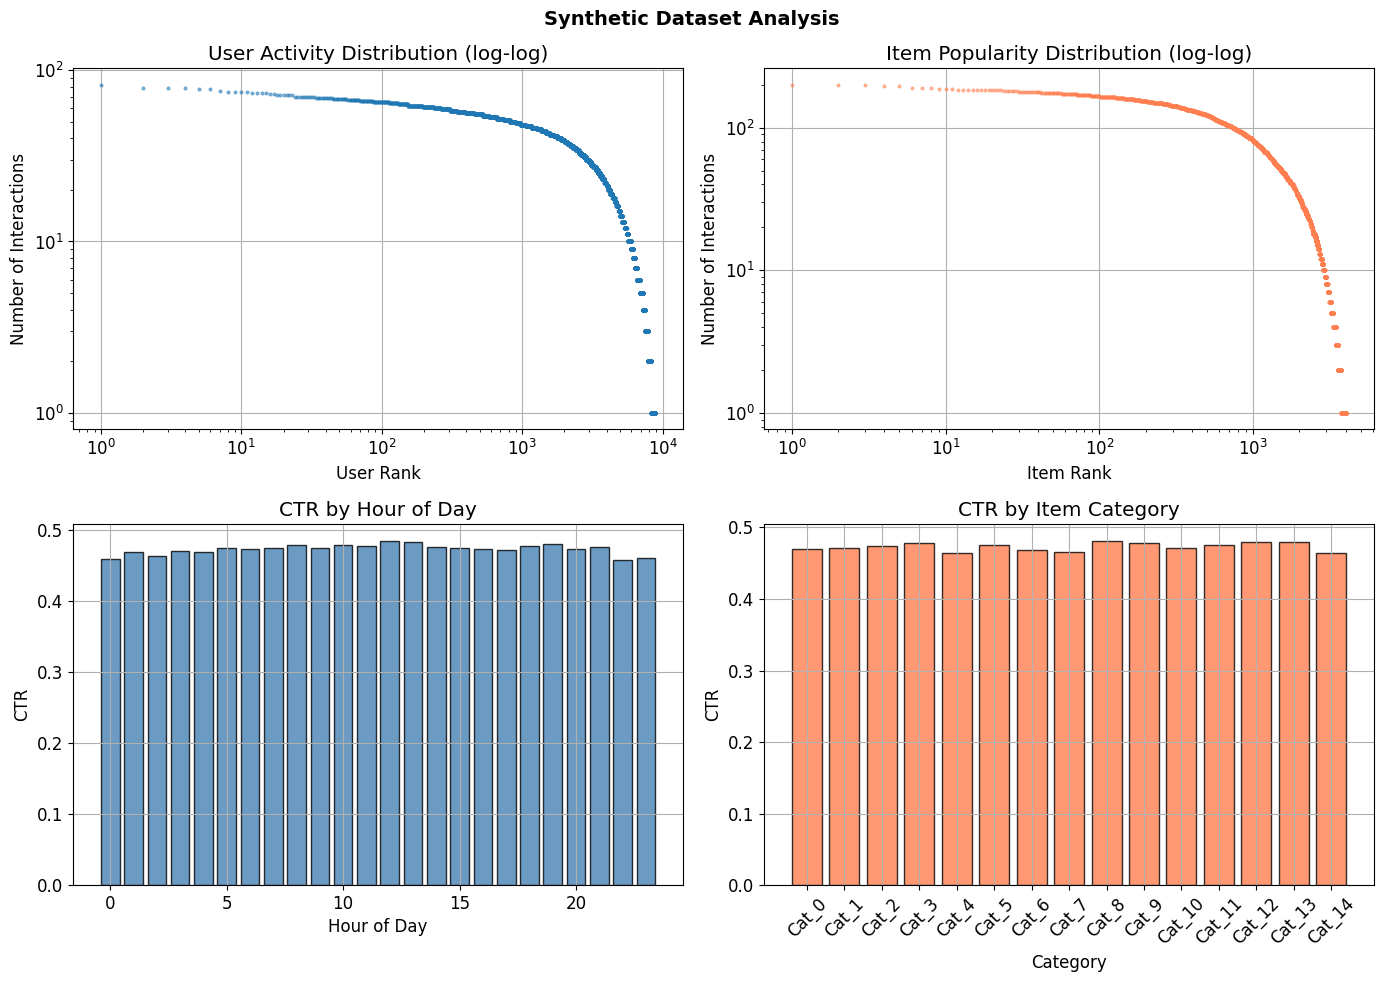

In [4]:
# Analyze the synthetic dataset properties
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# User activity distribution
user_counts = Counter(data['user_id'])
activity = sorted(user_counts.values(), reverse=True)
axes[0, 0].loglog(range(1, len(activity) + 1), activity, 'o', markersize=2, alpha=0.5)
axes[0, 0].set_xlabel('User Rank')
axes[0, 0].set_ylabel('Number of Interactions')
axes[0, 0].set_title('User Activity Distribution (log-log)')

# Item popularity distribution
item_counts = Counter(data['item_id'])
popularity = sorted(item_counts.values(), reverse=True)
axes[0, 1].loglog(range(1, len(popularity) + 1), popularity, 'o', markersize=2, alpha=0.5, color='coral')
axes[0, 1].set_xlabel('Item Rank')
axes[0, 1].set_ylabel('Number of Interactions')
axes[0, 1].set_title('Item Popularity Distribution (log-log)')

# CTR by hour
hour_ctr = defaultdict(list)
for h, l in zip(data['hour'], data['label']):
    hour_ctr[h].append(l)
hours = sorted(hour_ctr.keys())
ctrs = [np.mean(hour_ctr[h]) for h in hours]
axes[1, 0].bar(hours, ctrs, color='steelblue', edgecolor='black', alpha=0.8)
axes[1, 0].set_xlabel('Hour of Day')
axes[1, 0].set_ylabel('CTR')
axes[1, 0].set_title('CTR by Hour of Day')

# CTR by category
cat_ctr = defaultdict(list)
for c, l in zip(data['item_category'], data['label']):
    cat_ctr[c].append(l)
cats = sorted(cat_ctr.keys())[:15]
cat_ctrs = [np.mean(cat_ctr[c]) for c in cats]
axes[1, 1].bar([f'Cat_{c}' for c in cats], cat_ctrs, color='coral', edgecolor='black', alpha=0.8)
axes[1, 1].set_xlabel('Category')
axes[1, 1].set_ylabel('CTR')
axes[1, 1].set_title('CTR by Item Category')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.suptitle('Synthetic Dataset Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Benchmarking Methodology

### Common Pitfalls in RecSys Benchmarking

1. **Inconsistent data processing**: Different filtering criteria (e.g., 5-core vs 10-core)
2. **Different splitting strategies**: Random vs temporal vs leave-one-out
3. **Different negative sampling**: 100 random negatives vs all items
4. **Hyperparameter tuning fairness**: Some models tuned more than others
5. **Evaluation protocol**: Full ranking vs sampled ranking

> **⚠️ Common Pitfall:** Evaluating with sampled negatives (e.g., 100 random negatives per positive) can give very different results than full ranking. Krichene & Rendle (2020) showed that sampled metrics can lead to contradictory conclusions about which method is better.

### Best Practices

1. Use standardized frameworks (RecBole, LensKit)
2. Report processing details (filtering, splitting)
3. Full-ranking evaluation when possible
4. Statistical significance tests
5. Report multiple metrics
6. Include baselines (popularity, random)

In [5]:
# Demonstrate how preprocessing choices affect results
np.random.seed(42)

# Generate a simple dataset
n_u, n_i = 1000, 500
n_inter = 50000

users = np.random.zipf(1.5, n_inter) % n_u
items = np.random.zipf(1.5, n_inter) % n_i
ratings = np.clip(np.random.normal(3.5, 1, n_inter), 1, 5)

def filter_k_core(users, items, ratings, k=5):
    """Keep only users and items with at least k interactions."""
    for _ in range(10):  # Iterate until stable
        user_counts = Counter(users)
        item_counts = Counter(items)
        
        mask = np.array([user_counts[u] >= k and item_counts[i] >= k 
                        for u, i in zip(users, items)])
        
        if mask.all():
            break
        users = users[mask]
        items = items[mask]
        ratings = ratings[mask]
    
    return users, items, ratings


# Compare different k-core thresholds
k_values = [1, 3, 5, 10, 20]
results = []

print(f"{'K-Core':<10} {'Interactions':<15} {'Users':<10} {'Items':<10} {'Density':<12}")
print("-" * 57)

for k in k_values:
    u_filtered, i_filtered, r_filtered = filter_k_core(
        users.copy(), items.copy(), ratings.copy(), k=k
    )
    n_u_f = len(set(u_filtered))
    n_i_f = len(set(i_filtered))
    n_inter_f = len(u_filtered)
    density = n_inter_f / (n_u_f * n_i_f) * 100 if n_u_f > 0 and n_i_f > 0 else 0
    
    results.append({'k': k, 'interactions': n_inter_f, 'users': n_u_f, 
                   'items': n_i_f, 'density': density})
    print(f"{k:<10} {n_inter_f:<15} {n_u_f:<10} {n_i_f:<10} {density:<12.4f}%")

print("\nNote: Higher k-core filtering produces denser but smaller datasets.")
print("This makes evaluation easier but less representative of real conditions.")

K-Core     Interactions    Users      Items      Density     
---------------------------------------------------------
1          50000           927        500        10.7875     %
3          49515           618        480        16.6919     %
5          48407           359        412        32.7278     %


10         46071           181        237        107.3991    %
20         43359           102        107        397.2787    %

Note: Higher k-core filtering produces denser but smaller datasets.
This makes evaluation easier but less representative of real conditions.


## 4. RecBole and LensKit Overview

### RecBole
A comprehensive, open-source recommendation library built on PyTorch.

Key features:
- 90+ models implemented (from UserKNN to latest transformer models)
- Standardized data processing and evaluation
- Unified training/evaluation pipeline
- Configuration-based experiment management

```python
# Example RecBole usage (conceptual - not runnable without install)
from recbole.quick_start import run_recbole

result = run_recbole(
    model='BPR',
    dataset='ml-100k',
    config_dict={
        'embedding_size': 64,
        'learning_rate': 0.001,
        'eval_args': {'split': {'RS': [0.8, 0.1, 0.1]}}
    }
)
```

### LensKit
A Python toolkit focused on offline evaluation of recommendation algorithms.

Key features:
- Clean API for recommendation experiments
- Built-in cross-validation
- Integration with pandas for data handling
- Focus on reproducibility

> **🔑 Pro Tip:** For research, always compare against numbers reported by standardized frameworks rather than reimplementing baselines yourself. Implementation details (e.g., negative sampling strategy, learning rate schedule) can easily cause 5-10% variation in metrics.

In [6]:
# Simulate a proper benchmarking workflow
np.random.seed(42)

class BenchmarkSuite:
    """Simple benchmarking framework for RecSys."""
    
    def __init__(self, data, n_users, n_items):
        self.data = data
        self.n_users = n_users
        self.n_items = n_items
    
    def temporal_split(self, test_ratio=0.2):
        """Temporal train/test split."""
        sorted_idx = np.argsort(self.data['timestamp'])
        split = int(len(sorted_idx) * (1 - test_ratio))
        
        train_idx = sorted_idx[:split]
        test_idx = sorted_idx[split:]
        
        train = {k: v[train_idx] for k, v in self.data.items()}
        test = {k: v[test_idx] for k, v in self.data.items()}
        return train, test
    
    def evaluate_model(self, train, test, predict_fn, k=10):
        """Evaluate a model on test data."""
        # Build test ground truth: relevant items per user
        user_relevant = defaultdict(set)
        for u, i, l in zip(test['user_id'], test['item_id'], test['label']):
            if l == 1:
                user_relevant[u].add(i)
        
        # Build train items (to exclude from recommendations)
        user_train_items = defaultdict(set)
        for u, i in zip(train['user_id'], train['item_id']):
            user_train_items[u].add(i)
        
        ndcgs, hit_rates, mrrs = [], [], []
        eval_users = [u for u in user_relevant if len(user_relevant[u]) > 0]
        
        if len(eval_users) > 200:
            eval_users = np.random.choice(eval_users, 200, replace=False)
        
        for user in eval_users:
            scores = predict_fn(user)
            # Mask train items
            for i in user_train_items[user]:
                if i < len(scores):
                    scores[i] = -np.inf
            
            top_k = np.argsort(scores)[-k:][::-1]
            rel_set = user_relevant[user]
            
            # NDCG
            rels = [1 if item in rel_set else 0 for item in top_k]
            dcg = sum(r / np.log2(idx + 2) for idx, r in enumerate(rels))
            ideal = sorted(rels, reverse=True)
            idcg = sum(r / np.log2(idx + 2) for idx, r in enumerate(ideal))
            ndcgs.append(dcg / idcg if idcg > 0 else 0)
            
            # Hit Rate
            hit_rates.append(1.0 if len(set(top_k) & rel_set) > 0 else 0.0)
            
            # MRR
            rr = 0
            for idx, item in enumerate(top_k):
                if item in rel_set:
                    rr = 1.0 / (idx + 1)
                    break
            mrrs.append(rr)
        
        return {
            'NDCG@10': np.mean(ndcgs),
            'HitRate@10': np.mean(hit_rates),
            'MRR': np.mean(mrrs),
            'n_eval_users': len(eval_users)
        }


# Run benchmark with baseline models
suite = BenchmarkSuite(data, generator.n_users, generator.n_items)
train, test = suite.temporal_split(test_ratio=0.2)

# Baseline 1: Random
def random_recommender(user):
    return np.random.random(generator.n_items)

# Baseline 2: Popularity
item_pop_train = Counter(train['item_id'])
pop_scores = np.array([item_pop_train.get(i, 0) for i in range(generator.n_items)]).astype(float)
def popularity_recommender(user):
    return pop_scores + np.random.random(generator.n_items) * 0.01  # Break ties

# Baseline 3: User-average (recommend items clicked by similar users based on simple overlap)
def user_avg_recommender(user):
    # Simple: return items this user has seen weighted by label
    scores = np.zeros(generator.n_items)
    mask = train['user_id'] == user
    for i, l in zip(train['item_id'][mask], train['label'][mask]):
        # Use category-based expansion
        cat = generator.item_features['category'][i]
        same_cat = np.where(generator.item_features['category'] == cat)[0]
        scores[same_cat] += l * 0.1
    return scores + pop_scores * 0.001  # Fallback to popularity

# Evaluate all baselines
print(f"{'Model':<20} {'NDCG@10':<12} {'HitRate@10':<12} {'MRR':<12}")
print("-" * 56)

for name, fn in [('Random', random_recommender), 
                  ('Popularity', popularity_recommender),
                  ('User-Category', user_avg_recommender)]:
    results = suite.evaluate_model(train, test, fn)
    print(f"{name:<20} {results['NDCG@10']:<12.4f} {results['HitRate@10']:<12.4f} {results['MRR']:<12.4f}")

Model                NDCG@10      HitRate@10   MRR         
--------------------------------------------------------


Random               0.0074       0.0200       0.0036      


Popularity           0.0068       0.0150       0.0043      


User-Category        0.0237       0.0500       0.0171      


## 5. Reproducibility in RecSys Research

Reproducibility is a major challenge in RecSys research. Sun et al. (2020) found that many published results could not be reproduced, and simple baselines often outperform complex models when properly tuned.

### Reproducibility Checklist:

1. **Data**: Exact preprocessing steps, filtering criteria, split method
2. **Model**: All hyperparameters, initialization scheme, architecture details
3. **Training**: Learning rate, optimizer, number of epochs, early stopping criteria
4. **Evaluation**: Exact metrics, negative sampling strategy, number of eval users
5. **Code**: Public code repository with instructions
6. **Hardware**: GPU type, training time
7. **Randomness**: Random seeds, number of runs, confidence intervals

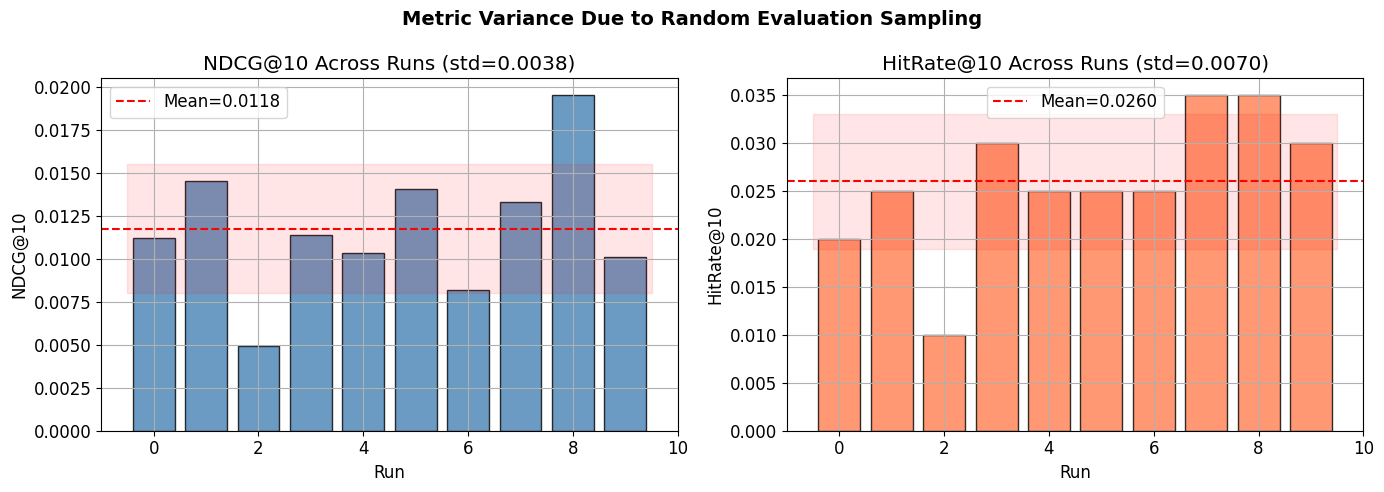

NDCG@10: 0.0118 +/- 0.0038
HitRate@10: 0.0260 +/- 0.0070

Always report mean +/- std over multiple runs!


In [7]:
# Demonstrate the impact of random seeds on results
ndcg_scores = []
hr_scores = []
n_runs = 10

for seed in range(n_runs):
    np.random.seed(seed)
    results = suite.evaluate_model(train, test, popularity_recommender)
    ndcg_scores.append(results['NDCG@10'])
    hr_scores.append(results['HitRate@10'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(range(n_runs), ndcg_scores, color='steelblue', edgecolor='black', alpha=0.8)
axes[0].axhline(np.mean(ndcg_scores), color='red', linestyle='--', 
                label=f'Mean={np.mean(ndcg_scores):.4f}')
axes[0].fill_between([-0.5, n_runs - 0.5], 
                      np.mean(ndcg_scores) - np.std(ndcg_scores),
                      np.mean(ndcg_scores) + np.std(ndcg_scores),
                      color='red', alpha=0.1)
axes[0].set_xlabel('Run')
axes[0].set_ylabel('NDCG@10')
axes[0].set_title(f'NDCG@10 Across Runs (std={np.std(ndcg_scores):.4f})')
axes[0].legend()

axes[1].bar(range(n_runs), hr_scores, color='coral', edgecolor='black', alpha=0.8)
axes[1].axhline(np.mean(hr_scores), color='red', linestyle='--',
                label=f'Mean={np.mean(hr_scores):.4f}')
axes[1].fill_between([-0.5, n_runs - 0.5],
                      np.mean(hr_scores) - np.std(hr_scores),
                      np.mean(hr_scores) + np.std(hr_scores),
                      color='red', alpha=0.1)
axes[1].set_xlabel('Run')
axes[1].set_ylabel('HitRate@10')
axes[1].set_title(f'HitRate@10 Across Runs (std={np.std(hr_scores):.4f})')
axes[1].legend()

plt.suptitle('Metric Variance Due to Random Evaluation Sampling', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"NDCG@10: {np.mean(ndcg_scores):.4f} +/- {np.std(ndcg_scores):.4f}")
print(f"HitRate@10: {np.mean(hr_scores):.4f} +/- {np.std(hr_scores):.4f}")
print(f"\nAlways report mean +/- std over multiple runs!")

---

## Exercises

### 🏋️ Exercise 1: Generate a Synthetic CTR Dataset with Realistic Feature Distributions

Extend the SyntheticDatasetGenerator to create a Criteo-like dataset.

In [8]:
def generate_criteo_like_dataset(n_samples=100000, n_numerical=13, n_categorical=26, seed=42):
    """
    Generate a Criteo-like CTR dataset.
    
    Requirements:
    - 13 numerical features with different distributions (normal, log-normal, exponential)
    - 26 categorical features with varying cardinalities (10 to 10000)
    - Realistic CTR (~3-5%)
    - Feature interactions that affect the label
    
    Returns:
        dict with 'numerical_features', 'categorical_features', 'labels'
    """
    # TODO: Implement this function
    # 1. Generate numerical features with diverse distributions
    # 2. Generate categorical features with power-law cardinality distributions
    # 3. Create labels based on a non-linear combination of features
    # 4. Ensure realistic CTR
    pass


# TODO: Generate the dataset and create visualizations:
# 1. Distribution of each numerical feature
# 2. Cardinality distribution of categorical features
# 3. CTR by numerical feature buckets
# 4. Feature correlation heatmap
pass

### 🏋️ Exercise 2: Benchmark Multiple Models

Implement and benchmark at least three simple models on the synthetic dataset.

In [9]:
# TODO:
# 1. Implement three models:
#    a. Popularity baseline
#    b. Matrix Factorization (from Chapter 1.3)
#    c. Simple MLP (from Chapter 1.5)
# 2. Use the BenchmarkSuite to evaluate all three
# 3. Run each model 5 times with different seeds
# 4. Report mean +/- std for NDCG@10, HitRate@10, MRR
# 5. Perform a statistical significance test (paired t-test)
# 6. Create a comprehensive comparison table and visualization
pass

### 🏋️ Exercise 3: Impact of Data Processing Choices

Study how different data processing choices affect benchmark results.

In [10]:
# TODO:
# Using the popularity baseline (simple and fast), measure how results change with:
# 1. Different k-core filtering: k = 1, 5, 10, 20
# 2. Different split strategies: random vs temporal
# 3. Different test ratios: 10%, 20%, 30%
# 4. Different evaluation K values: K = 5, 10, 20, 50
#
# For each variation:
# - Record NDCG and HitRate
# - Create a heatmap showing how each choice affects metrics
# - Discuss which choices matter most
pass

## Summary

In this notebook, we covered:

1. **Public datasets**: MovieLens, Amazon, Criteo, Taobao - their characteristics and use cases
2. **Dataset properties**: Sparsity, scale, feature types vary enormously across datasets
3. **Synthetic data generation**: Creating realistic datasets with power-law distributions
4. **Benchmarking methodology**: Proper splitting, evaluation, and reporting
5. **Reproducibility**: Random seed effects, multiple runs, statistical significance
6. **Frameworks**: RecBole and LensKit for standardized experiments

### Key Takeaways

- Always use standardized benchmarks and frameworks when possible
- Data processing choices (k-core, splitting) dramatically affect results
- Report results with confidence intervals (multiple random seeds)
- Simple baselines (popularity) are surprisingly strong and should always be included
- Sampled evaluation and full evaluation can give contradictory results

### Part 1 Complete!

Congratulations on completing Part 1: Foundations of Recommendation Systems. You now have a solid understanding of:
- The recommendation problem and its formulations
- Interaction data and its challenges
- Classical and embedding-based collaborative filtering
- Deep learning building blocks for RecSys
- Feature engineering and the modern pipeline
- Proper benchmarking methodology

In **Part 2**, we'll dive into modern deep recommendation models: from Wide&Deep to transformers.